Zadanie 10

Dla datasetu Wine Quality zidentyfikuj outliery w kolumnie alcohol metodą z-score
(wartości > mean ± 3*std). Usuń outliery i porównaj statystyki przed/po.

Dataset:
- Wine Quality

Wymagania:
- Oblicz z-scores
- Zidentyfikuj outliery (|z| > 3)
- Boxplot przed i po usunięciu
- Porównanie statystyk (mean, median, std)

Porównanie statystyk dla kolumny 'alcohol':
Statystyka  Przed usunięciem  Po usunięciu
      Mean         10.422983     10.404431
    Median         10.200000     10.100000
   Std Dev          1.065668      1.035413
     Count       1599.000000   1591.000000

Liczba usuniętych outlierów: 8


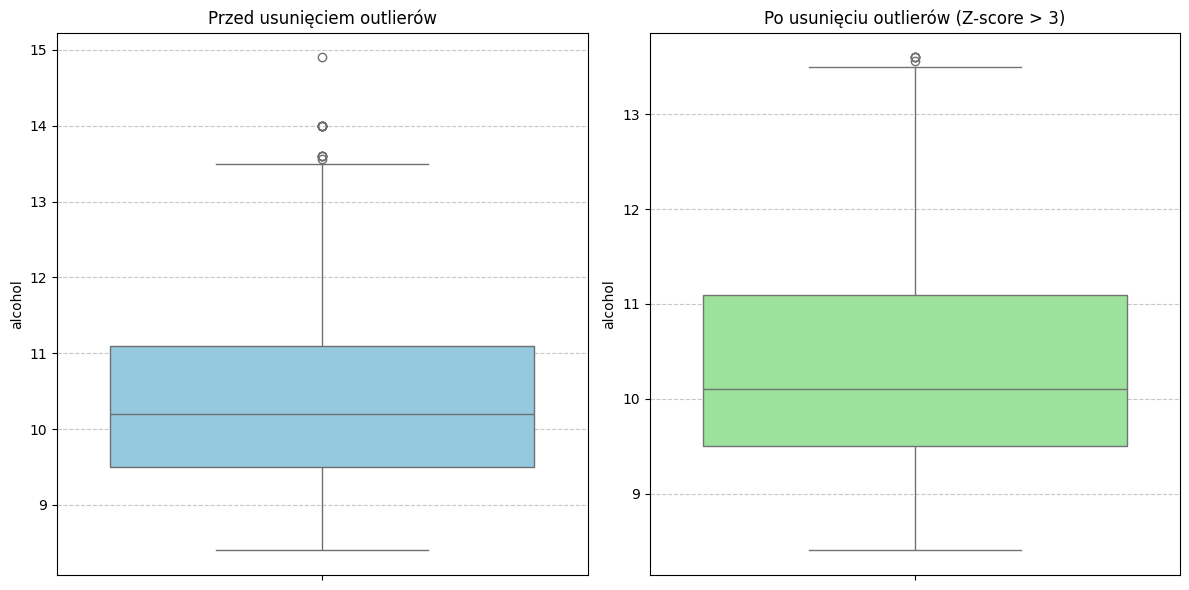

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Pobranie danych
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')

# Obliczanie Z-score dla kolumny 'alcohol'
z_scores = zscore(wine['alcohol'])
abs_z_scores = abs(z_scores)

# Identyfikacja outlierów (|z| > 3)
outliers = wine[abs_z_scores > 3]

# usuwanie outlierów
wine_clean = wine[abs_z_scores <= 3]

# Porównanie statystyk
stats_comparison = pd.DataFrame({
    'Statystyka': ['Mean', 'Median', 'Std Dev', 'Count'],
    'Przed usunięciem': [wine['alcohol'].mean(), wine['alcohol'].median(), wine['alcohol'].std(), len(wine)],
    'Po usunięciu': [wine_clean['alcohol'].mean(), wine_clean['alcohol'].median(), wine_clean['alcohol'].std(), len(wine_clean)]
})

print("Porównanie statystyk dla kolumny 'alcohol':")
print(stats_comparison.to_string(index=False))
print(f"\nLiczba usuniętych outlierów: {len(outliers)}")

# Wizualizaja (Boxplot przed i po)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=wine['alcohol'], color='skyblue')
plt.title('Przed usunięciem outlierów')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.boxplot(y=wine_clean['alcohol'], color='lightgreen')
plt.title('Po usunięciu outlierów (Z-score > 3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Granice cięcia: 7.23% - 13.62%
Liczba usuniętych outlierów: 8

     Statystyka       Przed          Po
        Średnia   10.422983   10.404431
        Mediana   10.200000   10.100000
     Odch. std.    1.065668    1.035413
Liczba rekordów 1599.000000 1591.000000


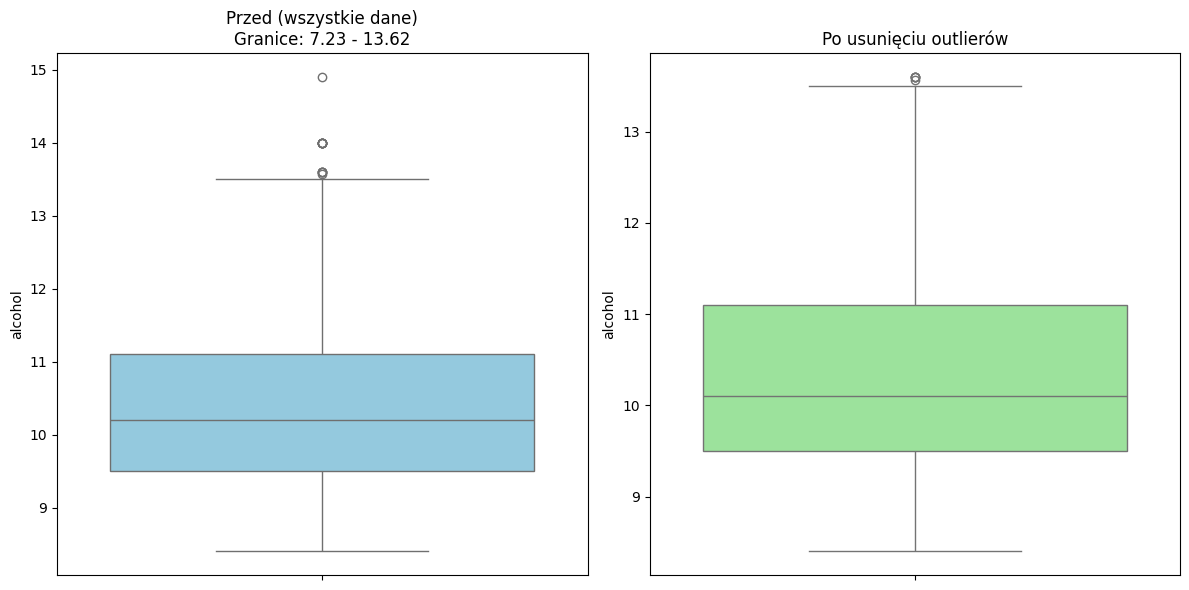

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')

# Obliczanie statystyk dla kolumny 'alcohol'
mean_val = wine['alcohol'].mean()
std_val = wine['alcohol'].std()

# Wyznaczenie granic (mean +/- 3*std)
lower_limit = mean_val - 3 * std_val
upper_limit = mean_val + 3 * std_val

# Identyfikacja i usuwanie outlierów
outliers = wine[(wine['alcohol'] < lower_limit) | (wine['alcohol'] > upper_limit)]
wine_clean = wine[(wine['alcohol'] >= lower_limit) & (wine['alcohol'] <= upper_limit)]

# Porównanie statystyk
stats_comparison = pd.DataFrame({
    'Statystyka': ['Średnia', 'Mediana', 'Odch. std.', 'Liczba rekordów'],
    'Przed': [mean_val, wine['alcohol'].median(), std_val, len(wine)],
    'Po': [wine_clean['alcohol'].mean(), wine_clean['alcohol'].median(), wine_clean['alcohol'].std(), len(wine_clean)]
})

print(f"Granice cięcia: {lower_limit:.2f}% - {upper_limit:.2f}%")
print(f"Liczba usuniętych outlierów: {len(outliers)}\n")
print(stats_comparison.to_string(index=False))

# Wizualizacja
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=wine['alcohol'], color='skyblue')
plt.title(f'Przed (wszystkie dane)\nGranice: {lower_limit:.2f} - {upper_limit:.2f}')

plt.subplot(1, 2, 2)
sns.boxplot(y=wine_clean['alcohol'], color='lightgreen')
plt.title('Po usunięciu outlierów')

plt.tight_layout()
plt.show()

Porównanie statystyk dla kolumny 'alcohol':
Statystyka  Przed usunięciem  Po usunięciu
      Mean         10.422983     10.404431
    Median         10.200000     10.100000
   Std Dev          1.065668      1.035413
     Count       1599.000000   1591.000000

Liczba usuniętych outlierów: 8


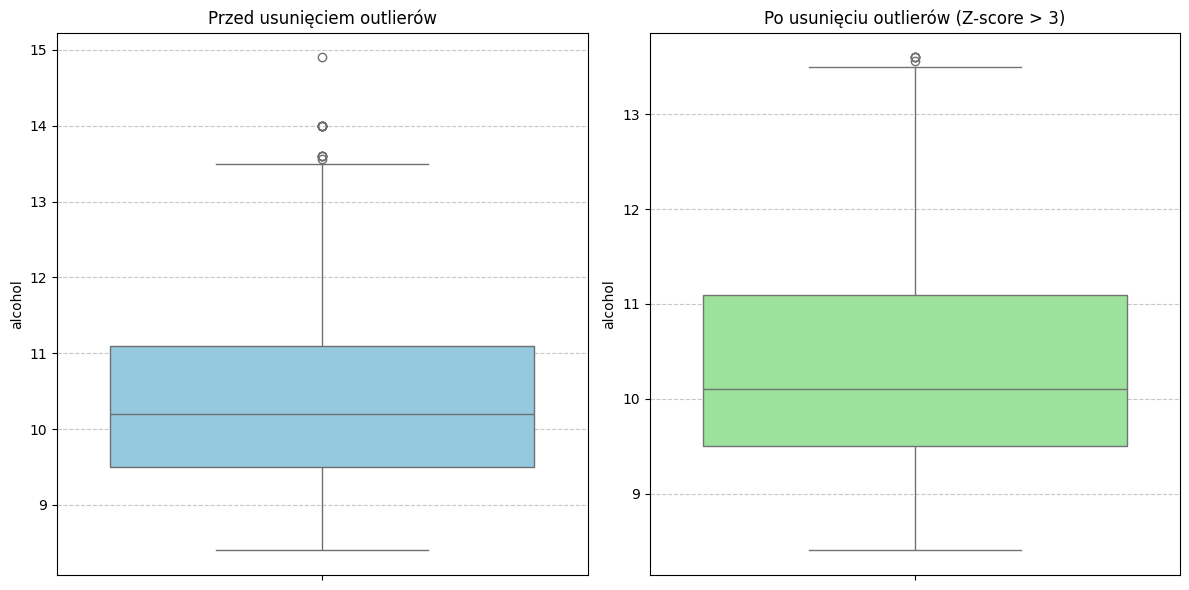

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Pobranie danych
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')

# Ręczne obliczanie z-score dla kolumny 'alcohol'
z_scores = (wine['alcohol'] - wine['alcohol'].mean()) / wine['alcohol'].std()
abs_z_scores = abs(z_scores)

# Identyfikacja outlierów (|z| > 3)
outliers = wine[abs_z_scores > 3]

# usuwanie outlierów
wine_clean = wine[abs_z_scores <= 3]

# Porównanie statystyk
stats_comparison = pd.DataFrame({
    'Statystyka': ['Mean', 'Median', 'Std Dev', 'Count'],
    'Przed usunięciem': [wine['alcohol'].mean(), wine['alcohol'].median(), wine['alcohol'].std(), len(wine)],
    'Po usunięciu': [wine_clean['alcohol'].mean(), wine_clean['alcohol'].median(), wine_clean['alcohol'].std(), len(wine_clean)]
})

print("Porównanie statystyk dla kolumny 'alcohol':")
print(stats_comparison.to_string(index=False))
print(f"\nLiczba usuniętych outlierów: {len(outliers)}")

# Wizualizaja (Boxplot przed i po)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=wine['alcohol'], color='skyblue')
plt.title('Przed usunięciem outlierów')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.boxplot(y=wine_clean['alcohol'], color='lightgreen')
plt.title('Po usunięciu outlierów (Z-score > 3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()